----
# **<span style="color:darkmagenta">PROYECTO EDA - BANK MARKETING</span>**
----

---
---
## <span style="color:gray">**1. Importación de librerías**</span> 📂

In [1]:
# Tratamiento de datos 
import numpy as np
import pandas as pd 

# Visualización de datos
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Configuración de ruta
import sys
sys.path.append('../')

# Importación de funciones personalizadas
from src.soporte3_EDA import *
from src.soporte2_limpieza import eliminar_columns

---
---
## <span style="color:gray">**2. Carga de datos**</span> 📥

In [3]:
# Utilizamos los datos que hemos guardado tras la limpieza
booking_eu = pd.read_csv("../data/output/booking_eu.csv")
reviews_limpio = pd.read_csv("../data/output/reviews_limpio.csv")

In [4]:
# Configuración para mostrar todas las columnas
pd.set_option('display.max_columns', None) 

----
# <span style="color:darkmagenta">**Desarrollo del proyecto - 3**</span> 
----


---
---
## <span style="color:gray">**Integración de datasets**</span> 🔗

'hotel', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
       'adults', 'children', 'babies', 'meal', 'country', 'market_segment',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'customer_type', 'adr', 'reservation_status', 'reservation_status_date',
       'arrival_year_month', 'total_nights', 'total_guests'

In [16]:
booking_agg = booking_eu.groupby(
    ['arrival_year_month', 'country']
).agg({
    # numéricas → medias
    'lead_time': 'mean',
    'stays_in_weekend_nights': 'mean',
    'stays_in_week_nights': 'mean',
    'adults': 'mean',
    'children': 'mean',
    'babies': 'mean',
    'previous_cancellations': 'mean',
    'previous_bookings_not_canceled': 'mean',
    'booking_changes': 'mean',
    'adr': 'mean',
    'total_nights': 'mean',
    'total_guests': 'mean',

    # categóricas → moda
    'hotel': lambda x: x.mode()[0],
    'meal': lambda x: x.mode()[0],
    'market_segment': lambda x: x.mode()[0],
    'is_repeated_guest': lambda x: x.mode()[0],
    'reserved_room_type': lambda x: x.mode()[0],
    'assigned_room_type': lambda x: x.mode()[0],
    'deposit_type': lambda x: x.mode()[0],
    'customer_type': lambda x: x.mode()[0],
    'reservation_status': lambda x: x.mode()[0],

}).reset_index()

In [18]:
reviews_agg = reviews_limpio.groupby(
    ['review_year_month', 'country']
).agg({
    # numéricas → medias
    'average_score': 'mean',
    'reviewer_score': 'mean',
    'total_number_of_reviews': 'mean',
    'total_number_of_reviews_reviewer_has_given': 'mean',
    'nights': 'mean',

    # categóricas → moda
    'hotel_name': lambda x: x.mode()[0],
    'reviewer_nationality': lambda x: x.mode()[0],
    'positive_tag': lambda x: x.mode()[0],
    'negative_tag': lambda x: x.mode()[0],
    'trip_type': lambda x: x.mode()[0],
    'group_type': lambda x: x.mode()[0]
}).reset_index()

In [19]:
df_final = booking_agg.merge(
    reviews_agg,
    left_on=['arrival_year_month', 'country'],
    right_on=['review_year_month', 'country'],
    how='inner'
).drop(columns=['review_year_month'])

Se observa que las variables total_nights (reservas) y nights (reseñas) no coinciden. Esto se debe a que provienen de fuentes distintas: mientras que total_nights recoge la duración de todas las reservas, nights únicamente incluye aquellas estancias que han generado una reseña.

Por tanto, nights está sujeta a un sesgo de selección, ya que no todos los clientes dejan opiniones. Debido a esta diferencia en cobertura, ambas variables no son directamente comparables.

En consecuencia, se decide utilizar total_nights como medida representativa de la duración de la estancia y descartar nights para evitar inconsistencias en el análisis.

### Análisis de las columnas

In [22]:
# Llamamos a la función para el análisis de columnas guardado en el archivo de soporte
columnas_df(df_final)



Las columnas del DataFrame que estamos analizando son:



Index(['arrival_year_month', 'country', 'lead_time', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'adr', 'total_nights', 'total_guests', 'hotel',
       'meal', 'market_segment', 'is_repeated_guest', 'reserved_room_type',
       'assigned_room_type', 'deposit_type', 'customer_type',
       'reservation_status', 'average_score', 'reviewer_score',
       'total_number_of_reviews', 'total_number_of_reviews_reviewer_has_given',
       'nights', 'hotel_name', 'reviewer_nationality', 'positive_tag',
       'negative_tag', 'trip_type', 'group_type'],
      dtype='str')



------------------------------------------------------------------

Información básica de las columnas:

<class 'pandas.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 34 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   arrival_year_month                          125 non-null    str    
 1   country                                     125 non-null    str    
 2   lead_time                                   125 non-null    float64
 3   stays_in_weekend_nights                     125 non-null    float64
 4   stays_in_week_nights                        125 non-null    float64
 5   adults                                      125 non-null    float64
 6   children                                    125 non-null    float64
 7   babies                                      125 non-null    float64
 8   previous_cancellations                      125 non-null    floa

,count,mean,std,min,25%,50%,75%,max
lead_time,125.0,74.98,38.20,0.67,43.39,70.53,98.43,216.45
stays_in_weekend_nights,125.0,0.92,0.28,0.00,0.77,0.95,1.06,1.81
stays_in_week_nights,125.0,2.49,0.53,1.33,2.21,2.44,2.73,4.93
adults,125.0,1.90,0.14,1.22,1.84,1.92,1.99,2.18
children,125.0,0.11,0.09,0.00,0.04,0.10,0.17,0.43
babies,125.0,0.01,0.01,0.00,0.00,0.00,0.01,0.03
previous_cancellations,125.0,0.03,0.33,0.00,0.00,0.00,0.00,3.67
previous_bookings_not_canceled,125.0,0.03,0.12,0.00,0.00,0.01,0.02,1.33
booking_changes,125.0,0.26,0.17,0.00,0.18,0.23,0.30,1.24
adr,125.0,106.03,27.98,53.85,83.23,102.30,126.38,201.51




Estadísticos de las variables categóricas:



,count,unique,top,freq
arrival_year_month,125,25,2015-08,5
country,125,5,austria,25
hotel,125,2,city_hotel,115
meal,125,2,bb,122
market_segment,125,4,online_ta,109
is_repeated_guest,125,1,no,125
reserved_room_type,125,1,a,125
assigned_room_type,125,2,a,123
deposit_type,125,1,no_deposit,125
customer_type,125,3,transient,111


---
---
## <span style="color:gray">**EDA sobre el dataset final**</span> 🧩

---

### <span style="color:darkgray">**1. Análisis univariado**</span>  

### <span style="color:darkgray">Distribución de las columnas numéricas</span>

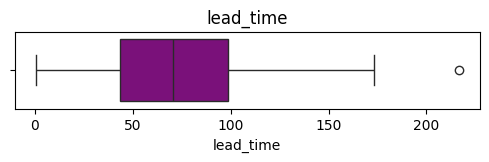

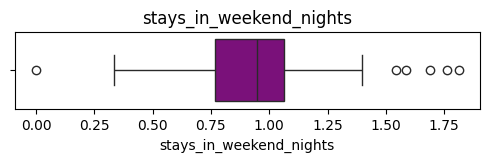

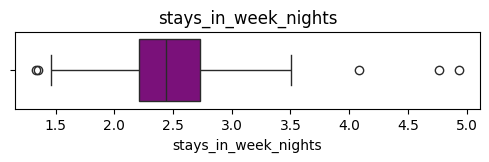

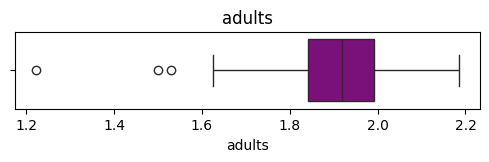

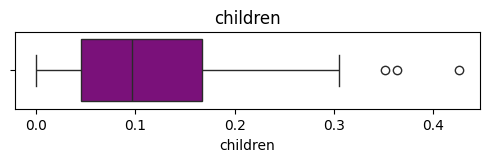

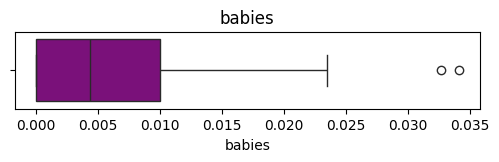

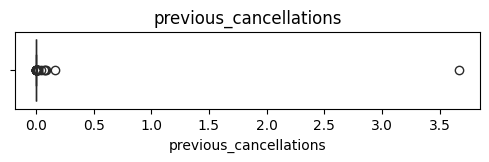

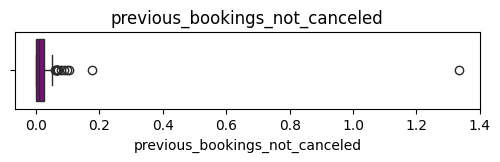

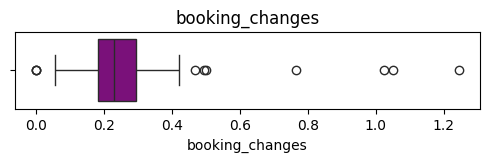

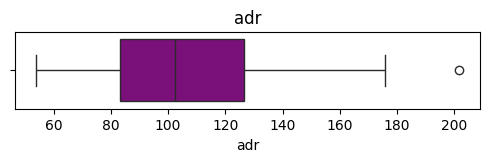

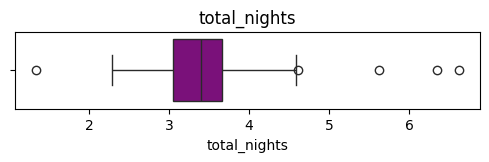

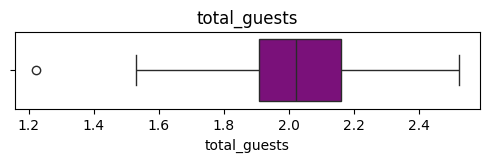

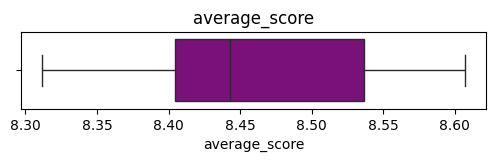

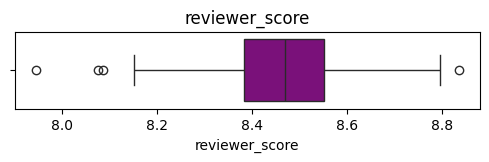

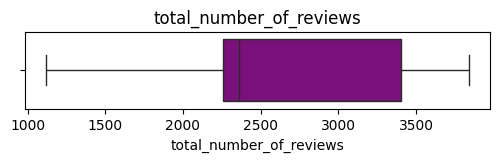

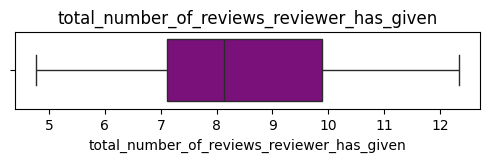

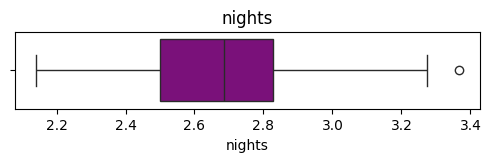

In [23]:
# Llamamos a la función de boxplots guardada en el archivo de soporte 
boxplots(df_final)

| Variable | Rango / Valores | Mediana | Observaciones |
|----------|----------------|---------|---------------|
| `age` | 18 – 100 | ~40 | La mayoría entre 30–50; varios outliers altos (70–100). |
| `campaign_contacts` | 1 – ~50 | 1–5 | Concentrado en valores bajos; algunos clientes reciben muchos contactos. |
| `previous_contacts` | 0 – 7 | 0 | Mayoría sin contactos previos; pocos casos dispersos. |
| `employment_variation_rate` | -3 a +1.5 | >0 | Distribución amplia, indica variación económica. |
| `consumer_price_index` | 92.5 – 94.8 | 93.7 | Poca variabilidad; indicador económico estable. |
| `consumer_confidence_index` | -50 a -30 | -40 | Algunos outliers; refleja cambios puntuales en confianza del consumidor. |
| `euribor_3m_rate` | 1 – 5 | ~4 | Amplia variación en tasas de interés. |
| `number_employees` | 5000 – 5220 | ~5150 | Muy poca variabilidad; empresa estable en tamaño. |
| `year` | 2016-2018 | 2017 | Distribución relativamente simétrica. |
| `income` | 0 – 175000 | 80k–90k | Rango amplio; algunos clientes con ingresos muy altos. |
| `num_kids_home` | 0 – 2 | 1 | Distribución bastante uniforme; pocos casos extremos. |
| `num_teens_home` | 0 – 2 | 1 | Similar a `num_kids_home`; sin outliers. |
| `num_web_visits_month` | 1 – 32 | 15–18 | Distribución equilibrada. |

**Resumen general**

- Variables económicas (índices, tasas) → más estables o controladas

- Variables de comportamiento (contactos, visitas) → más dispersas y con outliers

- Variables demográficas (edad, hijos, ingresos) → muestran diversidad clara en clientes

A partir del análisis anterior, se ha identificado que las siguientes variables presentan una baja relevancia explicativa debido a su escasa variabilidad o limitada capacidad informativa:

`previous_contacts` 

- Esta variable muestra una alta concentración de valores en 0, por lo que esta variable apenas aporta información relevante.

`num_kids_home` / `num_teens_home`

- Estas variables tienen muy poca variación entre los registros, lo que dificulta que ayuden a diferenciar unos casos de otros.

`number_employees`

- Se observa que esta variable es prácticamente constante, por lo que no aporta información significativa para el análisis.


En consecuencia, eliminamos estas variables del conjunto de datos para simplificar el modelo y evitar que introduzcan ruido innecesario:

- Antes de eliminarlas, creamos una copia del DataFrame:

In [10]:
df_final = df_integrado.copy()

- Eliminamos las varibles mencionadas anteriormente:

In [11]:
df_final = eliminar_columns(df_final, ['previous_contacts', 'num_kids_home', 'num_teens_home', 'number_employees'])

- Guardamos el DataFrame:

In [12]:
df_final.to_csv("../data/output/df_final.csv", index=False)

---
### <span style="color:darkgray">Distribución de las columnas categóricas</span>

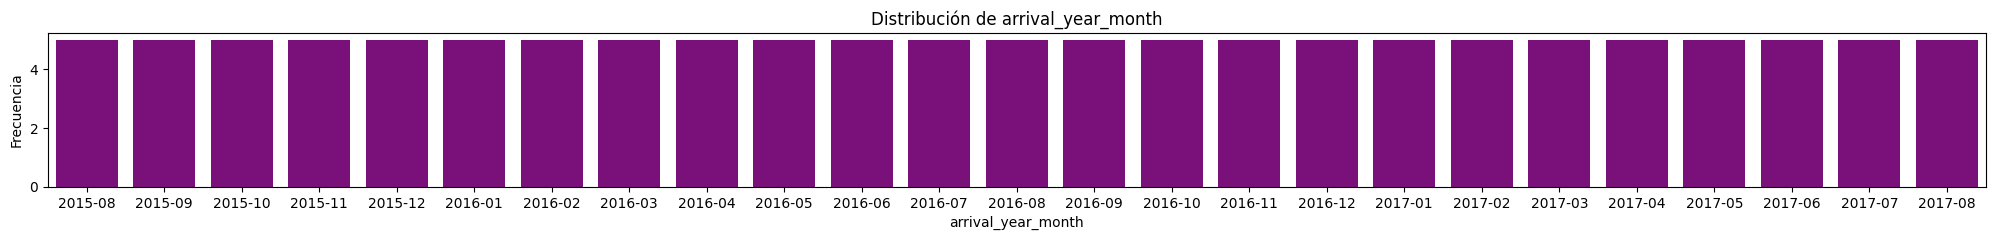

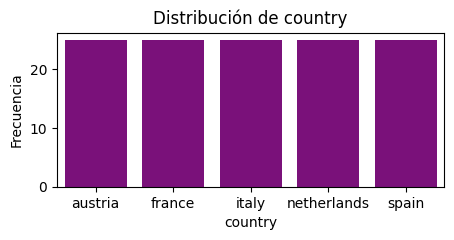

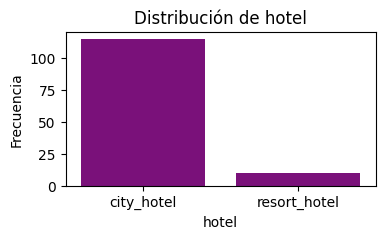

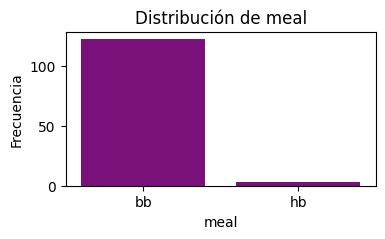

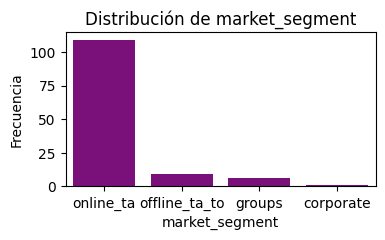

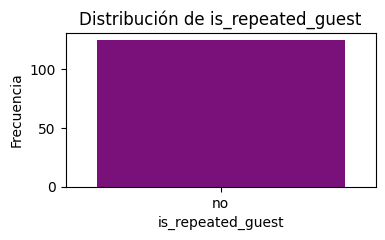

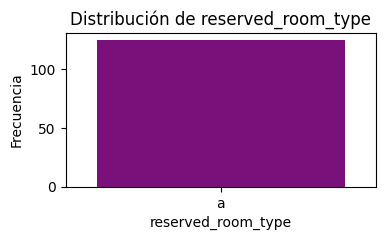

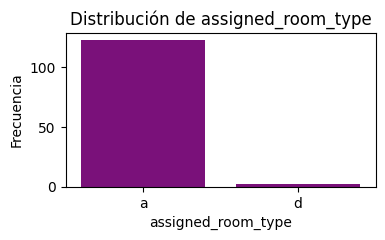

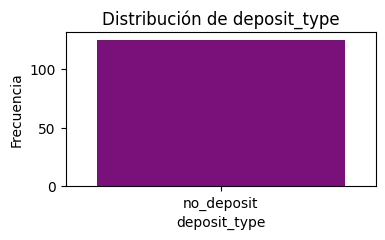

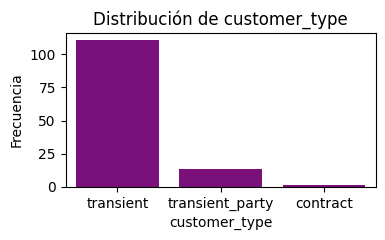

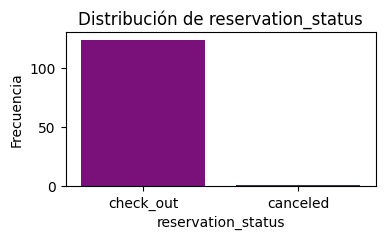

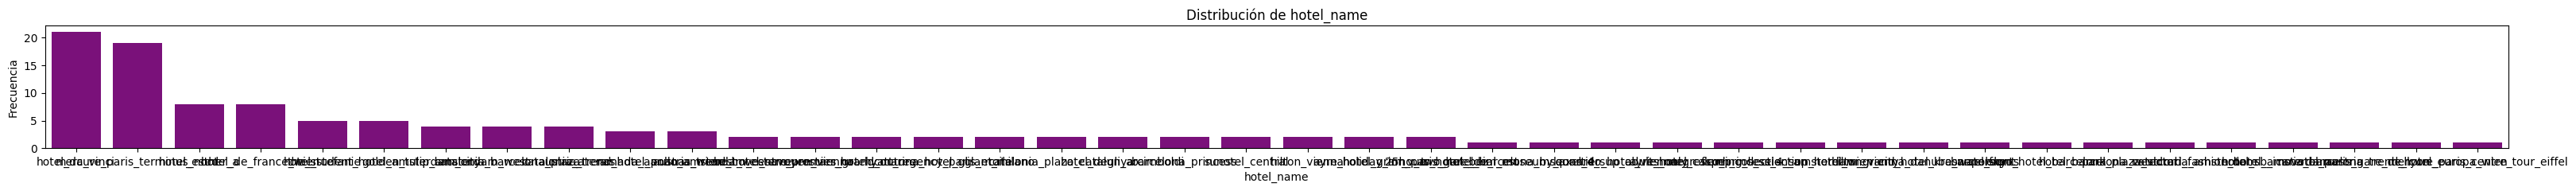

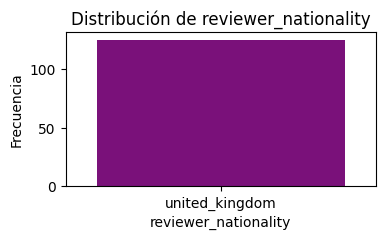

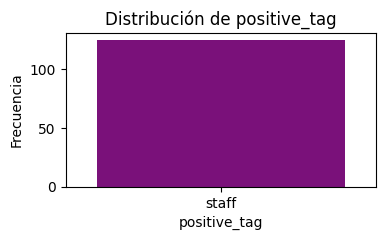

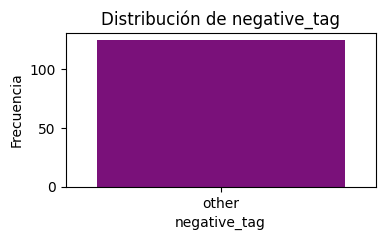

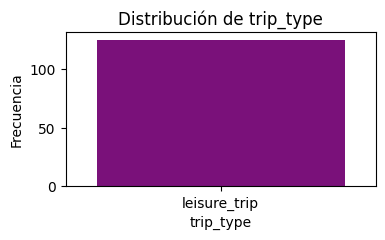

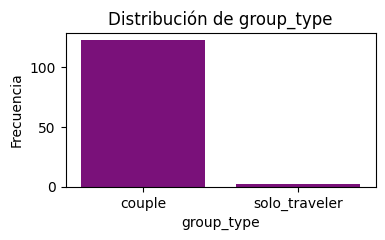

In [24]:
# Llamamos a la función de graficos_categoricos guardada en el archivo de soporte
graficos_categoricos(df_final)

| Variable                     | Predomina                                      | Observaciones                                                                 |
|-----------------------------|-----------------------------------------------|------------------------------------------------------------------------------|
| `job`                       | *administrative, blue-collar, technician*       | La mayoría pertenece a trabajos técnicos o administrativos.                 |
| `marital_status`            | *married, single*                                       | La mayoría de los clientes están casados.                                                         |
| `education_level`           | *university degree, high school*                | Predominan niveles educativos medios y superiores.                          |
| `default`                   | *no*                                            | Muy pocos clientes han incumplido pagos.                                    |
| `housing_loan`              | Ligeramente *yes*                               | Distribución bastante equilibrada.                                          |
| `personal_loan`             | *no*                                            | La mayoría no tiene préstamo personal.                                      |
| `contact_method`            | *mobile*                                        | Se usa más el móvil que el teléfono fijo.                                   |
| `previous_campaign_outcome` | *nonexistent*                                   | Muy pocos casos de success; muchos no fueron contactados antes.             |
| `subscribed`                | *no*                                            | Dataset desbalanceado (clase *no* mucho mayor que *yes*).                       |
| `contacted_before`          | *no*                                            | Confirma que la mayoría de los clientes no había sido contactada previamente.            |
| `month`                     | Ligeramente *November*                          | Distribución bastante equilibrada.            |

---
### <span style="color:darkgray">**2. Análisis bivariado**</span>  

### <span style="color:darkgray">Relación entre columnas numéricas y suscripción</span>  

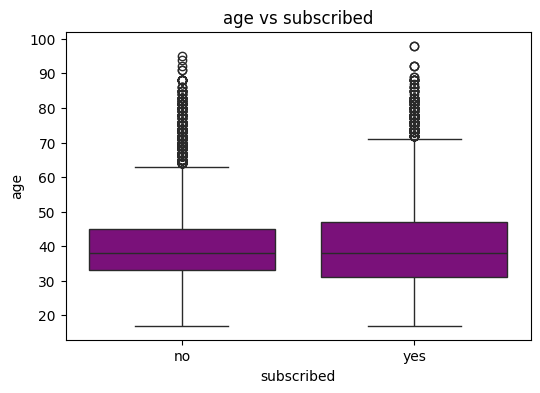

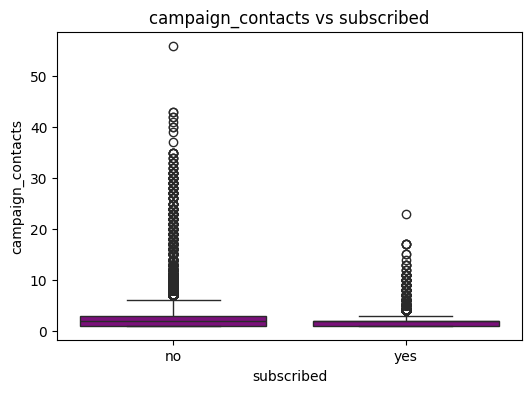

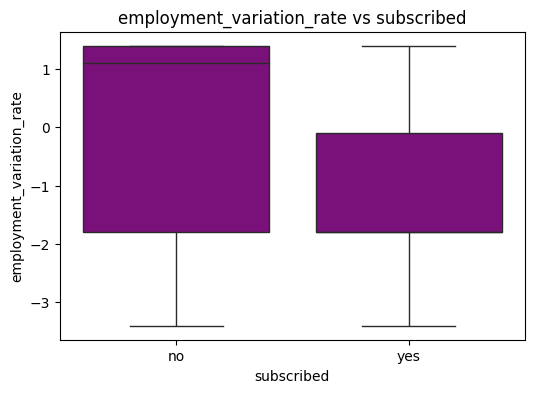

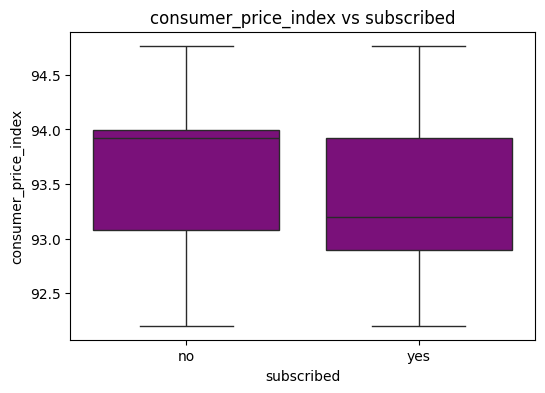

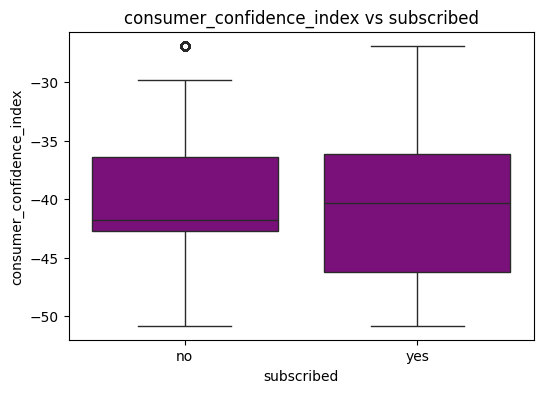

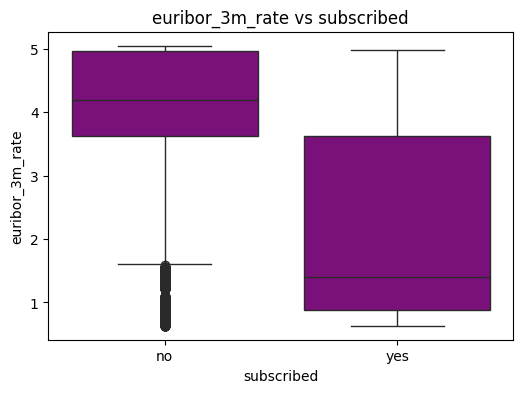

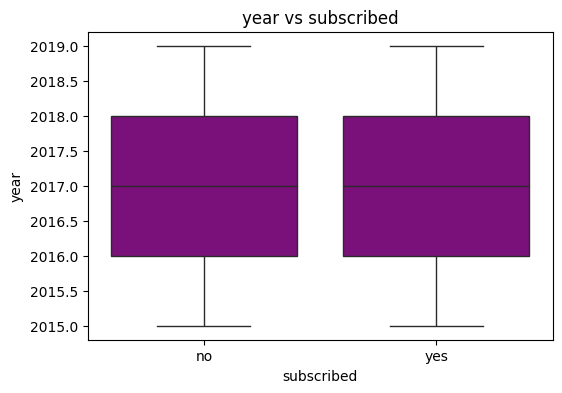

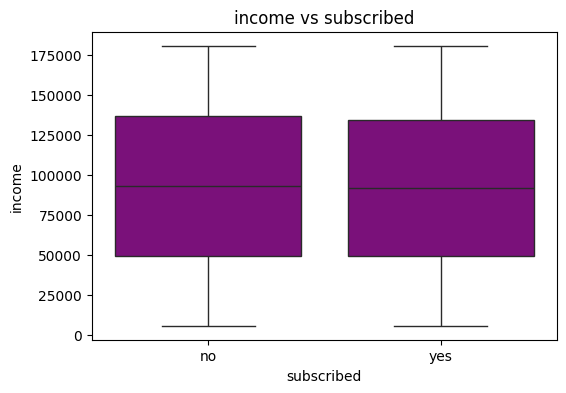

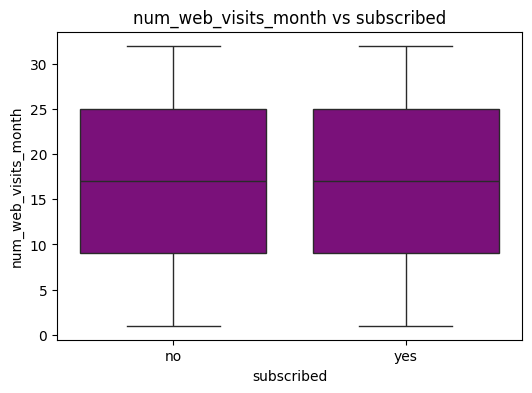

In [14]:
# Llamamos a la función de number_vs_target guardada en el archivo de soporte
number_vs_target(df_final, "subscribed")

***age vs subscribed***

- La mediana de edad para quienes se suscriben (yes) y no se suscriben (no) es bastante similar, alrededor de 35 años.
- La mayoría de los suscriptores están en el rango de 30–45 años.
- Hay varios valores atípicos en ambos grupos, especialmente por encima de los 60 años.

Conclusión: La edad por sí sola no parece un factor determinante fuerte para suscribirse.

***campaign_contacts vs subscribed***

- La mayoría de las personas han sido contactadas pocas veces (0–5) durante la campaña.
- Los no suscriptores muestran más valores atípicos en los contactos de campaña, con algunos recibiendo hasta 50 contactos.

Conclusión: Recibir más contactos no garantiza suscripción; de hecho, muchos que no se suscriben reciben más contactos, lo que sugiere saturación o contactos repetitivos sin éxito.

***employment_variation_rate vs subscribed***

- Los suscriptores tienden a tener una tasa de variación del empleo más baja (más cercana a cero o positiva), mientras que los no suscriptores tienen valores negativos más pronunciados.

Conclusión: Una economía o sector laboral más estable podría estar correlacionado con la suscripción.

***consumer_price_index vs subscribed***

- No hay una diferencia clara entre suscriptores y no suscriptores.
- La mediana y el rango son prácticamente iguales.

Conclusión: CPI no parece influir directamente en la decisión de suscribirse.

***consumer_confidence_index vs subscribed***

- Los valores medianos son similares entre ambos grupos.
- Hay algunos outliers positivos en los no suscriptores.

Conclusión: La confianza del consumidor no muestra un patrón claro con la suscripción.

***euribor_3m_rate vs subscribed***

- Los suscriptores tienden a registrarse cuando la tasa Euribor a 3 meses es más baja.
- Los no suscriptores muestran tasas más altas y más dispersión.

Conclusión: Las tasas de interés bajas podrían favorecer la suscripción.

***year vs subscribed***

- La distribución por años es muy similar entre suscriptores y no suscriptores.

Conclusión: El año de registro no influye significativamente en la suscripción.

***income vs subscribed***

- La mediana de ingresos es similar para ambos grupos.
- Ambos muestran una distribución amplia y outliers altos.

Conclusión: Los ingresos individuales no parecen ser un predictor fuerte de suscripción.

***num_web_visits_month vs subscribed***

- La mediana y rango son casi idénticos para ambos grupos.

Conclusión: La cantidad de visitas web al mes no diferencia claramente entre suscriptores y no suscriptores.



### <span style="color:darkgray">Relación entre columnas categóricas y suscripción</span>  

Calculamos la tasa de conversión para cada categoría de las variables categóricas:

In [15]:
# Llamamos a la función que calcula la tasa de conversión de las columnas categóricas guardada en el archivo de soporte
tasa_conversion_cat(df_final, 'subscribed')

VARIABLE: JOB

job
student           31.34
retired           25.20
unemployed        14.39
administrative    13.01
unknown           11.30
management        11.21
technician        10.85
self_employed     10.81
housemaid          9.88
entrepreneur       8.28
services           8.07
blue_collar        6.89
Name: subscribed, dtype: float64

--------------------------------------

VARIABLE: MARITAL_STATUS

marital_status
unknown     15.29
single      13.93
married     10.21
divorced    10.18
Name: subscribed, dtype: float64

--------------------------------------

VARIABLE: EDUCATION_LEVEL

education_level
illiterate             22.22
unknown                14.44
university_degree      13.74
professional_course    11.32
high_school            10.84
basic_4y               10.28
basic_6y                8.13
basic_9y                7.81
Name: subscribed, dtype: float64

--------------------------------------

VARIABLE: DEFAULT

default
no    11.27
si     0.00
Name: subscribed, dtype: float64

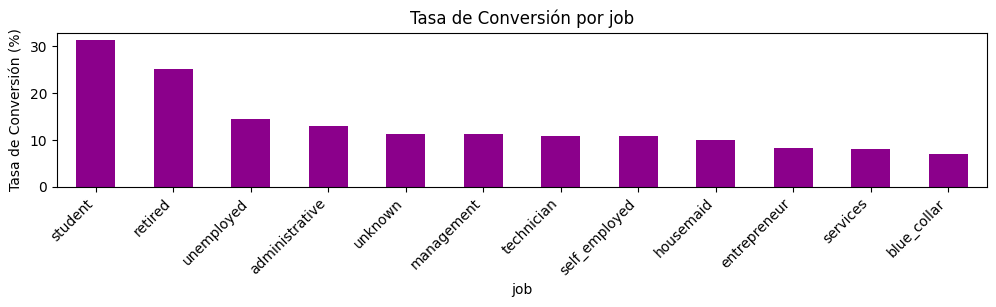

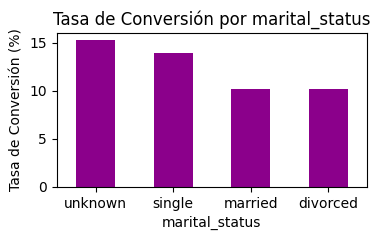

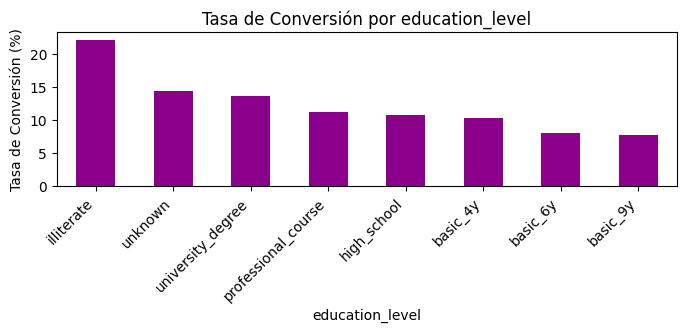

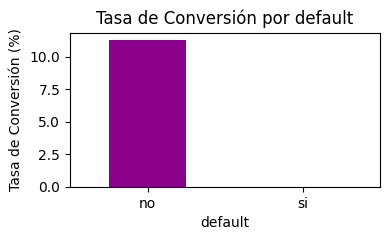

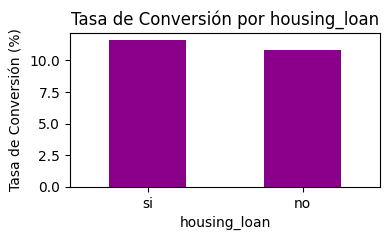

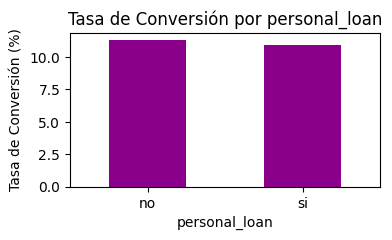

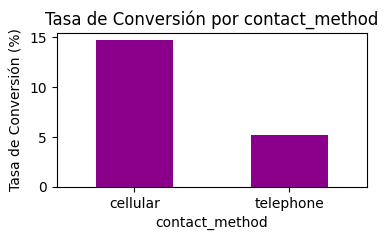

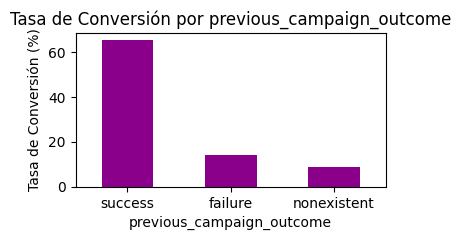

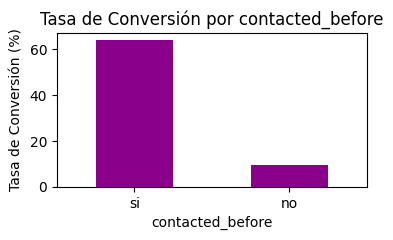

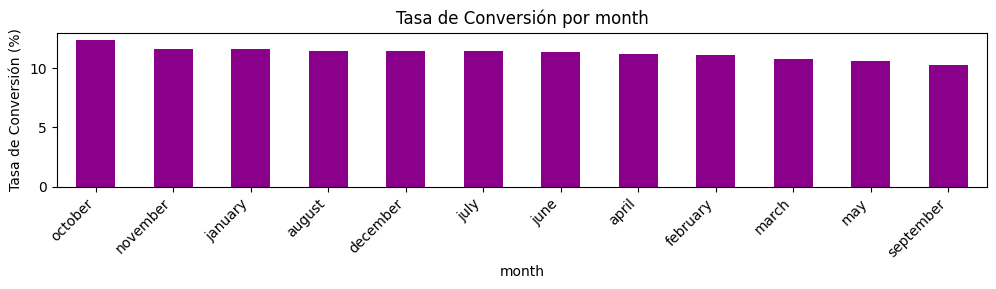

In [16]:
# Llamamos a la función que grafica la tasa de conversión de las columnas categóricas guardada en el archivo de soporte
grafs_conversion_cat(df_final, 'subscribed', rotar_columnas=('job', 'education_level', 'month'))

***job vs subscribed***

- Las categorías con mayor volumen son *administrative*, *blue-collar* y *technician*, sin embargo, tienen menor tasa de conversión que otras categorías.
- Los *students* y *retired* presentan una mayor proporción de suscripción.

Conclusión: La ocupación influye en la suscripción; perfiles como estudiantes y jubilados tienden a suscribirse más.

***marital_status vs subscribed***

- La mayoría de los clientes están casados (*married*).
- Los *single* presentan una proporción ligeramente mayor de suscripción.

Conclusión: El estado civil influye ligeramente; los solteros tienden a suscribirse más.

***education_level vs subscribed***

- La mayoría de los clientes tienen *university_degree* o *high_school*.
- Los clientes con educación universitaria muestran mayor proporción de suscripción.
- Los niveles básicos presentan menor conversión.

Conclusión: A mayor nivel educativo, mayor probabilidad de suscripción.

***default vs subscribed***

- La gran mayoría de los clientes no tiene historial de impagos.
- Hay muy pocos casos con default, lo que dificulta el análisis.

Conclusión: Variable poco informativa debido a su desbalance.

***housing_loan vs subscribed***

- La distribución entre clientes con y sin préstamo hipotecario es bastante equilibrada.
- Los que no tienen préstamo muestran una ligera mayor proporción de suscripción.

Conclusión: Tener préstamo hipotecario podría reducir levemente la probabilidad de suscripción, pero el efecto es bajo.

***personal_loan vs subscribed***

- La mayoría de los clientes no tiene préstamo personal.
- Los clientes sin préstamo personal presentan mayor proporción de suscripción.

Conclusión: Tener préstamos personales puede estar asociado con menor probabilidad de suscripción.

***contact_method vs subscribed***

- El contacto por móvil muestra muchas más suscripciones que el teléfono fijo.

Conclusión: El canal de contacto es un factor importante; el móvil es más efectivo.

***previous_campaign_outcome vs subscribed***

- Los clientes con resultado previo positivo tienen una tasa de suscripción muy alta.
- Los casos negativos presentan baja conversión.
- En los casos en los que no hubo contacto en la campaña previa la conversión es moderada.

Conclusión: El resultado de campañas anteriores es uno de los factores más determinantes.

***contacted_before vs subscribed***

- Los clientes contactados previamente tienen mayor proporción de suscripción.
- Los no contactados muestran menor conversión.

Conclusión: El seguimiento previo aumenta la probabilidad de suscripción.

***month vs subscribed***

- La distribución de suscripciones es relativamente uniforme entre meses.
- Algunos meses muestran ligeras variaciones, pero sin diferencias fuertes.

Conclusión: El mes tiene un impacto limitado en la suscripción.

### <span style="color:darkgray">**4. Análisis multivariado**</span>  

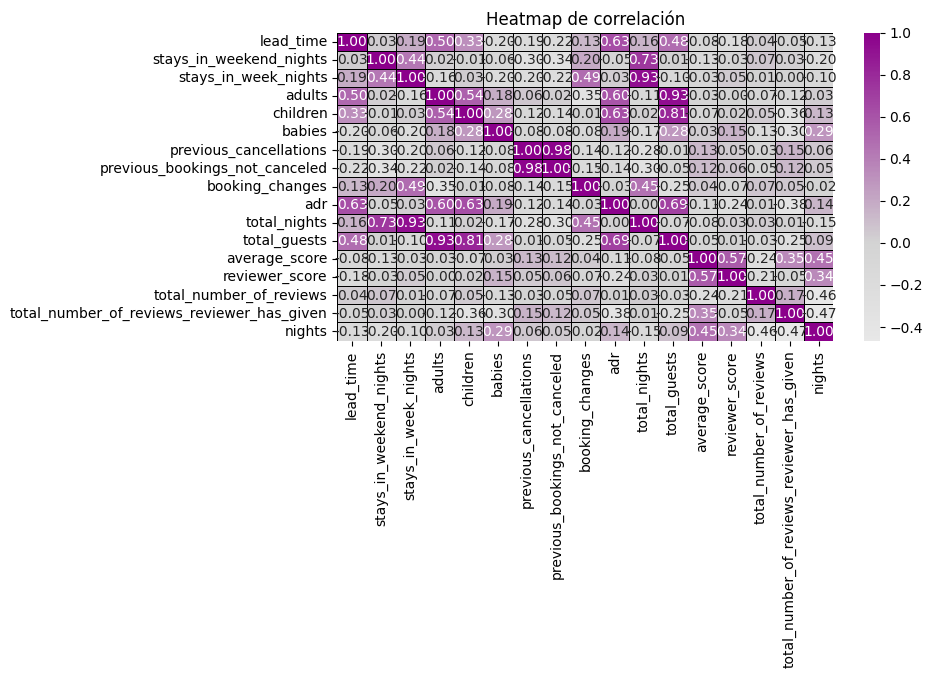

In [25]:
# Llamamos a la función que nos dibuja el heatmap guardada en el archivo de soporte
grafica_correlacion(df_final)

🟣 **Correlaciones más fuertes (positivas):**

**`employment_variation_rate` ↔ `euribor_3m_rate` (0.86)**

- Relación muy fuerte: cuando uno sube, el otro también.

**`employment_variation_rate` ↔ `consumer_price_index` (0.77)**

- Cuando sube el empleo, tiende a subir el índice de precios (inflación).

**`consumer_price_index` ↔ `euribor_3m_rate` (0.61)**

- Relación moderada-alta entre precios e interés.

🟢 **Correlaciones moderadas:**

**`consumer_confidence_index` ↔ euribor_3m_rate` (0.24)**

- Cuando suben las tasas de interés, la confianza del consumidor tiende a cambiar ligeramenteç.

**`employment_variation_rate` ↔ `consumer_confidence_index` (0.19)** 

- Un aumento en el empleo se asocia con un pequeño aumento en la confianza.

**`campaign_contacts` ↔ `employment_variation_rate` (0.15)** 

- El número de contactos en campañas tiene una leve relación con el empleo, pero su influencia es muy limitada.

⚪ **Correlaciones débiles o casi nulas:**  

**`age`, `income`, `year`, `num_web_visits_month`**

- Estas variables tienen valores cercanos a 0, indicando poca o ninguna relación lineal con las demás.

🔴 **Correlaciones negativas:**

- No hay relaciones negativas relevantes (todas están cerca de 0).


---
---
## <span style="color:gray">**Insights**</span> 💡

El análisis exploratorio muestra que las variables macroeconómicas, especialmente `employment_variation_rate` y `euribor_3m_rate`, presentan la mayor relación con la suscripción. Además, estas variables están fuertemente correlacionadas entre sí, lo que indica posible multicolinealidad.

Por otro lado, variables individuales como `age`, `income` y `num_web_visits_month` presentan correlaciones débiles, sugiriendo una baja influencia directa en la decisión del cliente.

En cuanto a variables categóricas, `previous_campaign_outcome` destaca como el factor más influyente, seguido por `contact_method` y `jo`b. Variables como `education_level` y `marital_status` muestran un impacto moderado, mientras que `default`, `housing_loan` y `personal_loan` tienen poca relevancia.

Finalmente, se observa que `campaign_contacts` no presenta una relación positiva clara con la suscripción, lo que indica que un mayor número de contactos no necesariamente mejora los resultados.

---
---
## <span style="color:gray">**Conclusiones finales**</span> 📝

Los resultados sugieren que la decisión de suscripción está más influenciada por factores externos, como las condiciones macroeconómicas, que por características personales del cliente.

El historial de campañas emerge como el factor más determinante, lo que indica que la información de interacciones previas es clave para predecir el comportamiento futuro.

Asimismo, el canal de contacto y ciertas variables sociodemográficas (como la ocupación) juegan un papel relevante, mientras que variables financieras como préstamos tienen un impacto limitado.

Dado que algunas variables macroeconómicas contienen información redundante, es recomendable realizar una selección cuidadosa de variables para evitar problemas de multicolinealidad en los modelos predictivos.

Por último, incrementar la cantidad de contactos no garantiza una mayor tasa de conversión, por lo que se recomienda optimizar la estrategia de contacto en lugar de simplemente aumentarla.